In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('Social_Network_Ads.csv')

In [13]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [14]:
df=df.iloc[: , 2:]

In [15]:
df.tail()

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


**Train Test and Split**

In [16]:
from sklearn.model_selection import train_test_split
xTr , xTs , yTr , yTs = train_test_split(df[['Age','EstimatedSalary']] , df['Purchased'] , test_size=0.3 , random_state=0)

In [17]:
xTr.shape , xTs.shape

((280, 2), (120, 2))

# **Standardization**

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xTr_scaled = scaler.fit_transform(xTr) #fit learns from the data like mean and sd
xTs_scaled= scaler.transform(xTs)

In [19]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [20]:
xTr

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [21]:
xTs

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000
...,...,...
216,49,65000
259,45,131000
49,31,89000
238,46,82000


In [22]:
xTr_scaled  # the problem is that we get numpy array as scaled values ..so we need to convert it again to df

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [23]:
xTr_scaled=pd.DataFrame(xTr_scaled)

In [24]:
xTr_scaled

,0,1
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [25]:
xTs_scaled=pd.DataFrame(xTs_scaled)

In [26]:
np.round(xTr.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [27]:
np.round(xTr_scaled.describe(), 1)

,0,1
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# **Effect of Scaling**

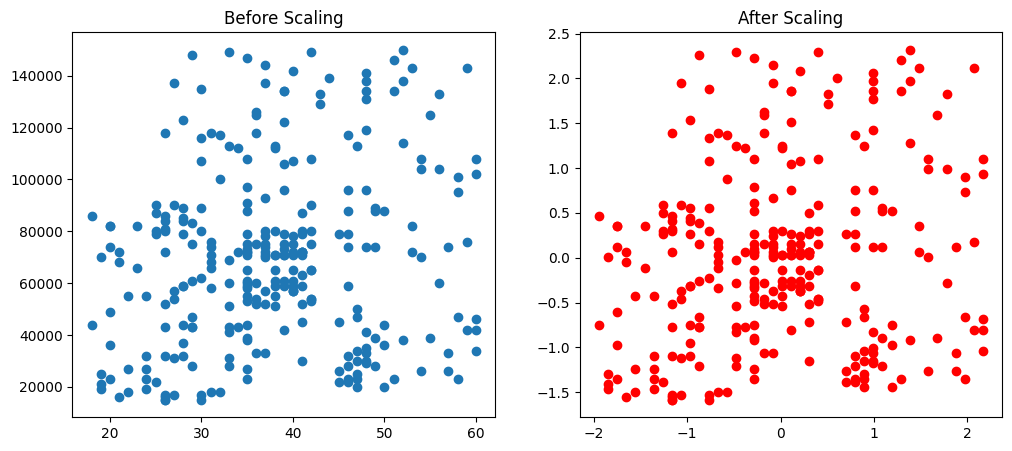

In [28]:
fig, (area1, area2) = plt.subplots(ncols=2, figsize=(12, 5))

area1.scatter(xTr['Age'], xTr['EstimatedSalary'])
area1.set_title("Before Scaling")

area2.scatter(xTr_scaled[0], xTr_scaled[1],color='red')
area2.set_title("After Scaling")

plt.show()


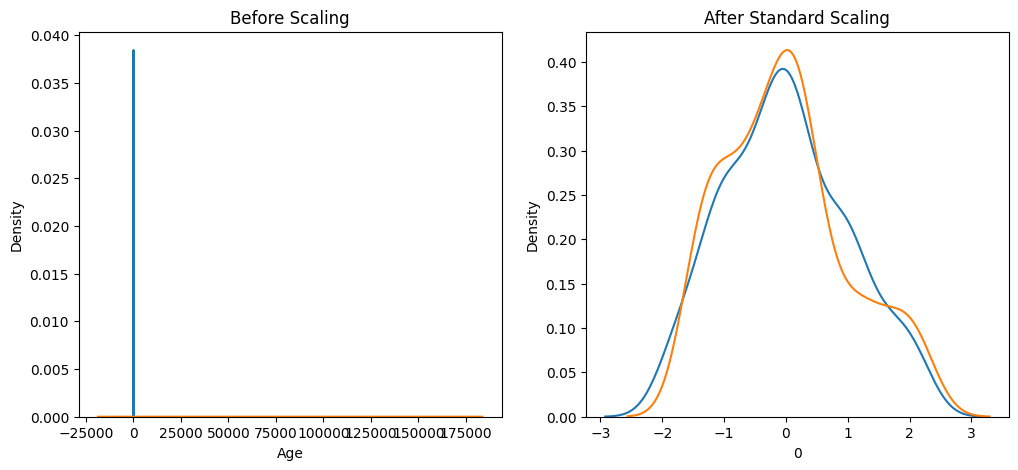

In [30]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(xTr['Age'], ax=ax1)
sns.kdeplot(xTr['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(xTr_scaled[0], ax=ax2)
sns.kdeplot(xTr_scaled[1], ax=ax2)
plt.show()

# **Comparison of Distribution**

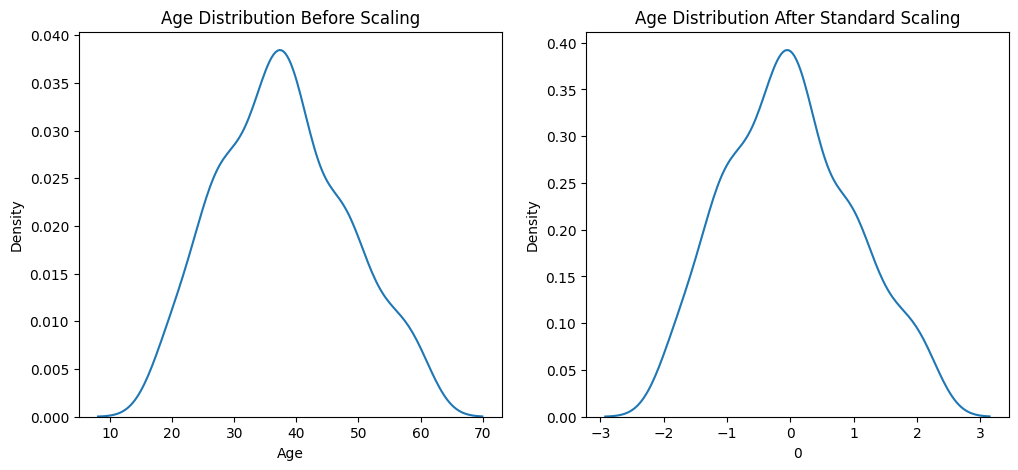

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(xTr['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(xTr_scaled[0], ax=ax2)
plt.show()